In [2]:
# Feature Scaling is a technique to standerdize the independent features present in the data in fixed range.
# 1. Standardization
# 2. Normalization: minmaxscaler, robustscaler

# Standerdization Also known as Z-scaler  Normalization.
# Standerdization of age column age' = (age - mean(age))/ std.
# the mean of age' after Standerdization will be 0, and std will be 1.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
data = pd.read_csv(r'Social_Network_Ads.csv') 
# print (data)
data = data.iloc[:,2:]
print(data.head())
print(data.shape)


   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
(400, 3)


In [8]:
x_train, x_test, y_train, y_test = train_test_split(data.drop('Purchased', axis=1),data['Purchased'], test_size=.3)

print(x_test.shape)
print(x_train.shape)

scale = StandardScaler()
# fit the scale to the train set,it will learn parameter
scale.fit(x_train)
print(scale.mean_) 



(120, 2)
(280, 2)
[3.71321429e+01 7.07892857e+04]


In [9]:
 # Transform train and test 
x_train_scale = scale.transform(x_train)
x_test_scale = scale.transform(x_test)

print("Scale learn the train set:  age mean,  salary mean = ",scale.mean_)

# x_train_scale is a multidimention array, to convert it into dataframe 
x_train_scale = pd.DataFrame(x_train_scale, columns=x_train.columns)
x_test_scale = pd.DataFrame(x_test_scale, columns=x_test.columns)

print(x_train_scale)



Scale learn the train set:  age mean,  salary mean =  [3.71321429e+01 7.07892857e+04]
          Age  EstimatedSalary
0   -1.079793         0.034395
1    2.024136         0.687799
2   -0.012818        -0.391738
3   -0.691802        -0.619009
4   -0.788800         0.119622
..        ...              ...
275 -1.855775         0.432119
276 -0.691802        -1.584911
277 -0.206813         0.488937
278  1.830140         1.767336
279 -0.109815         2.079834

[280 rows x 2 columns]


In [10]:

print("Discribing x_train dataset (before scaling)")
print(np.round(x_train.describe()))

print("Discribing x_train_scaled dataset (before scaling)")
print(np.round(x_train_scale.describe()))               # we can see mean = 0, std = 1


Discribing x_train dataset (before scaling)
         Age  EstimatedSalary
count  280.0            280.0
mean    37.0          70789.0
std     10.0          35263.0
min     18.0          15000.0
25%     29.0          43000.0
50%     36.0          70000.0
75%     45.0          88250.0
max     60.0         150000.0
Discribing x_train_scaled dataset (before scaling)
         Age  EstimatedSalary
count  280.0            280.0
mean    -0.0              0.0
std      1.0              1.0
min     -2.0             -2.0
25%     -1.0             -1.0
50%     -0.0             -0.0
75%      1.0              0.0
max      2.0              2.0


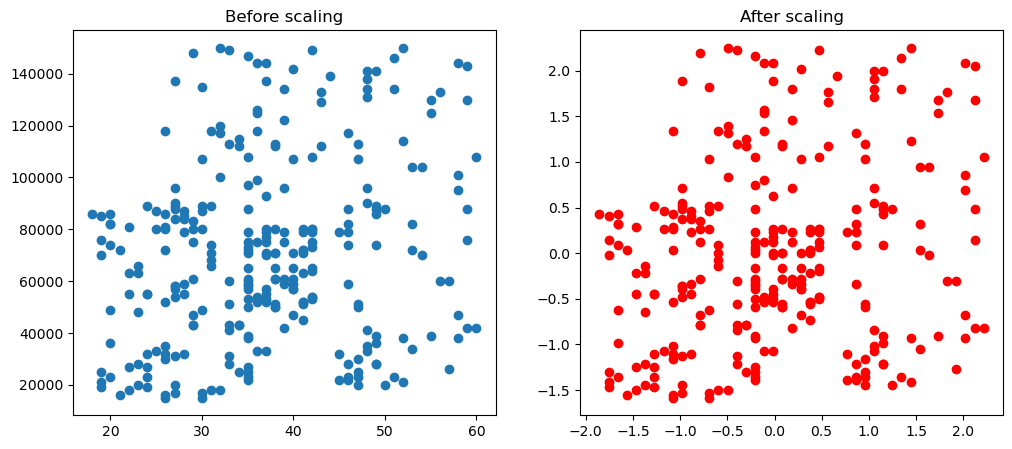

In [24]:
# ploting 
fig,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before scaling")
ax2.scatter(x_train_scale['Age'], x_train_scale['EstimatedSalary'],color="red")
ax2.set_title("After scaling")
plt.show()


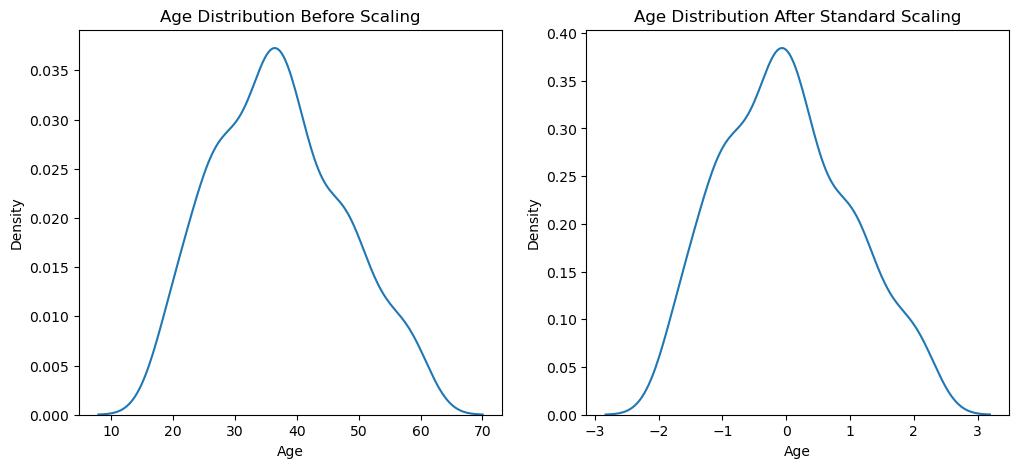

In [ ]:

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scale['Age'], ax=ax2)
sns.kdeplot(x_train_scale['EstimatedSalary'], ax=ax2)
plt.show()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
# after
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scale['Age'], ax=ax2)
plt.show()
